# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Uman-66/Flyrank-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!pip -q install duckdb scikit-learn pandas matplotlib seaborn

from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError("HF_TOKEN was not found in Colab Secrets.")

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

DAILY_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/**/*.parquet"
)

print("Environment ready.")

Environment ready.


## 1. Question

### Research question

Can historical search-performance signals be used to rank content items by their observed likelihood of experiencing a future performance decline?

### Decision supported

This analysis supports content refresh prioritization. The goal is to identify which anonymized content items should be reviewed first based on historical search-performance patterns.

The output is a ranked decision-support queue rather than a claim about Google's ranking algorithm or a causal estimate of the effect of refreshing content.

### Unit of analysis

Each observation represents one content item for one client on one report date.

The final model produces a score for eligible content items and ranks them from highest to lowest refresh-review priority.


In [2]:
# Section 1: setup and dataset overview

!pip -q install duckdb scikit-learn pandas matplotlib

from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError("HF_TOKEN was not found in Colab Secrets.")

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

DAILY_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/**/*.parquet"
)

# Confirm dataset coverage
coverage = con.sql(f"""
SELECT
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date,
    COUNT(*) AS total_rows
FROM read_parquet(
    '{DAILY_PATH}',
    hive_partitioning=true
)
""").df()

display(coverage)

# Show available monthly partitions
months = con.sql(f"""
SELECT
    month,
    COUNT(*) AS rows
FROM read_parquet(
    '{DAILY_PATH}',
    hive_partitioning=true
)
GROUP BY month
ORDER BY month
""").df()

display(months)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_date,last_date,total_rows
0,2025-01-27,2026-06-30,78835655


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows
0,2025-01,1297
1,2025-02,75985
2,2025-03,167859
3,2025-04,285114
4,2025-05,349923
5,2025-06,329201
6,2025-07,469794
7,2025-08,704962
8,2025-09,845813
9,2025-10,2165471


## 2. Data

### Dataset

The analysis uses the gated FlyRank internship warehouse release on Hugging Face.

The primary table is `fact_content_daily_performance`, which contains daily performance observations for pseudonymized client and content entities.

### Modeling window

The analysis uses observations available before the held-out evaluation period to construct historical features.

* Training period: observations before May 2026
* Test period: May 2026
* June 2026 is used only to observe the future outcome for May observations.
* June is not used as a feature or training period.

### Grain

The intended analytical grain is:

`report_date + client_hash_id + content_hash_id`

### Included fields

The analysis uses search and engagement measurements available in the daily performance table, including clicks, impressions, average position, engaged sessions, and the client-level Google Search Console availability indicator.

### Exclusions

Client names, domains, URLs, private queries, credentials, raw exports, and other identifying information are excluded from the public analysis.

Rows without sufficient historical observations or without the information required to construct the future outcome are excluded from modeling.

### Public-safe framing

All content and client identifiers remain pseudonymized. The results are presented as directional decision-support evidence rather than causal evidence about search-engine behavior.


In [3]:
# Section 2: inspect schema, grain, missingness, and monthly coverage

# Inspect the table schema
schema = con.sql(f"""
DESCRIBE
SELECT *
FROM read_parquet(
    '{DAILY_PATH}',
    hive_partitioning=true
)
""").df()

display(schema)

# Verify the expected grain on a manageable modeling window.
# May + June are the important final periods.
grain_check = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    COUNT(*) AS rows_per_grain
FROM read_parquet(
    '{DAILY_PATH}',
    hive_partitioning=true
)
WHERE month IN ('2026-05', '2026-06')
GROUP BY
    report_date,
    client_hash_id,
    content_hash_id
HAVING COUNT(*) > 1
ORDER BY rows_per_grain DESC
LIMIT 20
""").df()

print("Duplicate grain keys:")
display(grain_check)

# Count rows and distinct dates for the modeling period
period_summary = con.sql(f"""
SELECT
    month,
    COUNT(*) AS rows,
    COUNT(DISTINCT report_date) AS distinct_dates,
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date
FROM read_parquet(
    '{DAILY_PATH}',
    hive_partitioning=true
)
WHERE month IN ('2026-05', '2026-06')
GROUP BY month
ORDER BY month
""").df()

display(period_summary)

# Check missingness in the fields we intend to use
missingness = con.sql(f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE report_date IS NULL) AS missing_report_date,
    COUNT(*) FILTER (WHERE client_hash_id IS NULL) AS missing_client_id,
    COUNT(*) FILTER (WHERE content_hash_id IS NULL) AS missing_content_id,
    COUNT(*) FILTER (WHERE gsc_clicks IS NULL) AS missing_clicks,
    COUNT(*) FILTER (WHERE gsc_impressions IS NULL) AS missing_impressions,
    COUNT(*) FILTER (WHERE gsc_avg_position IS NULL) AS missing_position,
    COUNT(*) FILTER (WHERE ga4_engaged_sessions IS NULL) AS missing_engagement
FROM read_parquet(
    '{DAILY_PATH}',
    hive_partitioning=true
)
WHERE month IN ('2026-05', '2026-06')
""").df()

display(missingness)

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate grain keys:


,report_date,client_hash_id,content_hash_id,rows_per_grain
0,2026-06-13,client_1a730cb2640a1abf,content_0a21add649629840,2
1,2026-06-13,client_1a730cb2640a1abf,content_0ffd552a735a66ab,2
2,2026-06-13,client_1a730cb2640a1abf,content_f85822ce54f90378,2
3,2026-06-13,client_1a730cb2640a1abf,content_ff51845ed161bfb4,2
4,2026-06-13,client_1a730cb2640a1abf,content_8f5be8e45452dda7,2
5,2026-06-13,client_1a730cb2640a1abf,content_a4990373223aa784,2
6,2026-06-13,client_1a730cb2640a1abf,content_b5aec9a8a2ee7fb0,2
7,2026-06-13,client_1a730cb2640a1abf,content_c426957b8369a333,2
8,2026-06-13,client_1a730cb2640a1abf,content_5ea66e7cd969a440,2
9,2026-06-13,client_1a730cb2640a1abf,content_62a6c7628cfd006f,2


,month,rows,distinct_dates,first_date,last_date
0,2026-05,11687376,31,2026-05-01,2026-05-31
1,2026-06,11694072,30,2026-06-01,2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,missing_report_date,missing_client_id,missing_content_id,missing_clicks,missing_impressions,missing_position,missing_engagement
0,23381448,0,0,0,0,0,15129124,4817730


## 3. Methodology

### Feature construction

Features are calculated using only observations available before the prediction date. Historical windows summarize recent search and engagement behavior for each client-content pair.

The feature set contains:

1. Mean Google Search Console clicks over the previous 7 observations.
2. Mean Google Search Console impressions over the previous 7 observations.
3. Mean Google Search Console average position over the previous 7 observations.
4. Mean GA4 engaged sessions over the previous 7 observations.
5. Recent click change compared with the preceding 7-observation period.
6. Recent impression change compared with the preceding 7-observation period.
7. Recent position change compared with the preceding 7-observation period.
8. Recent engagement change compared with the preceding 7-observation period.
9. Client-level Google Search Console availability.

### Label definition

The prediction target is future decline.

For an observation date, the future outcome is the mean clicks over the following 7 observations. A row is labeled `1` when its future 7-observation mean clicks are below its historical 7-observation mean clicks. Otherwise it is labeled `0`.

The future observations are used only for constructing the target and are never used as model features.

### Baseline

A transparent baseline ranks content using the number of recent signals that are below training-period median thresholds.

### Models

Two supervised models are evaluated:

* Logistic Regression
* Random Forest

### Validation design

The split is time-aware.

Earlier observations are used for training and May 2026 is held out as the evaluation period. June 2026 supplies the future observations needed to determine the May outcome label.

### Leakage checks

Features are constructed with trailing windows ending one observation before the prediction date. Future-window measurements are used only for the target. Test-period information is not used to calculate training thresholds.


In [4]:
# Section 3: build the feature table and future-decline label

# ---------------------------------------------------------
# 3A. Select a manageable modeling population
# ---------------------------------------------------------
#
# The full warehouse contains tens of millions of rows.
# We do not need to calculate expensive window functions
# over the entire warehouse for this capstone.
#
# Instead, we:
#
# 1. Identify content-client pairs present in May 2026.
# 2. Randomly select a controlled sample of pairs.
# 3. Calculate historical features only for those pairs.
#
# The sampling is done before the expensive window functions.

SAMPLE_PAIRS = 25000

print("Selecting content-client pairs from May 2026...")

con.execute("""
DROP TABLE IF EXISTS sampled_pairs
""")

con.execute(f"""
CREATE TEMP TABLE sampled_pairs AS

SELECT
    client_hash_id,
    content_hash_id

FROM (
    SELECT DISTINCT
        client_hash_id,
        content_hash_id

    FROM read_parquet(
        '{DAILY_PATH}',
        hive_partitioning=true
    )

    WHERE month = '2026-05'
)

ORDER BY
    hash(
        CAST(client_hash_id AS VARCHAR)
        || '_'
        || CAST(content_hash_id AS VARCHAR)
    )

LIMIT {SAMPLE_PAIRS}
""")

sampled_count = con.sql("""
SELECT COUNT(*) AS sampled_pairs
FROM sampled_pairs
""").df()

print("Sampled content-client pairs:")
display(sampled_count)

Selecting content-client pairs from May 2026...
Sampled content-client pairs:


,sampled_pairs
0,25000


In [5]:
# Section 3: calculate historical features for sampled pairs

# ---------------------------------------------------------
# 3B. Build the feature table
# ---------------------------------------------------------
#
# Only March-June observations for the sampled pairs are
# processed.
#
# March and April provide historical observations.
# May is the held-out prediction period.
# June provides the future outcome for May.

FEATURE_SQL = f"""

WITH selected_data AS (

    SELECT
        d.report_date,
        d.client_hash_id,
        d.content_hash_id,
        d.client_has_gsc,
        d.gsc_data_available,
        d.gsc_clicks,
        d.gsc_impressions,
        d.gsc_avg_position,
        d.ga4_engaged_sessions

    FROM read_parquet(
        '{DAILY_PATH}',
        hive_partitioning=true
    ) AS d

    INNER JOIN sampled_pairs AS p
        ON d.client_hash_id = p.client_hash_id
        AND d.content_hash_id = p.content_hash_id

    WHERE d.month IN (
        '2026-03',
        '2026-04',
        '2026-05',
        '2026-06'
    )
),

base AS (

    SELECT
        *,

        -- Recent 7 historical observations

        AVG(gsc_clicks) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS clicks_mean_7,

        AVG(gsc_impressions) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS impressions_mean_7,

        AVG(gsc_avg_position) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS position_mean_7,

        AVG(ga4_engaged_sessions) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS engagement_mean_7,


        -- Previous 7 observations before the recent 7

        AVG(gsc_clicks) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 14 PRECEDING AND 8 PRECEDING
        ) AS clicks_mean_previous_7,

        AVG(gsc_impressions) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 14 PRECEDING AND 8 PRECEDING
        ) AS impressions_mean_previous_7,

        AVG(gsc_avg_position) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 14 PRECEDING AND 8 PRECEDING
        ) AS position_mean_previous_7,

        AVG(ga4_engaged_sessions) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 14 PRECEDING AND 8 PRECEDING
        ) AS engagement_mean_previous_7,


        -- Number of previous click observations

        COUNT(gsc_clicks) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS prior_click_observations,


        -- Future 7 observations used only for the label

        AVG(gsc_clicks) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 1 FOLLOWING AND 7 FOLLOWING
        ) AS future_clicks_mean_7,

        COUNT(gsc_clicks) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 1 FOLLOWING AND 7 FOLLOWING
        ) AS future_click_observations

    FROM selected_data
)

SELECT
    *,

    -- Recent versus previous changes

    clicks_mean_7 - clicks_mean_previous_7
        AS clicks_change_7,

    impressions_mean_7 - impressions_mean_previous_7
        AS impressions_change_7,

    position_mean_7 - position_mean_previous_7
        AS position_change_7,

    engagement_mean_7 - engagement_mean_previous_7
        AS engagement_change_7,


    -- Relative changes

    CASE
        WHEN clicks_mean_previous_7 IS NOT NULL
             AND clicks_mean_previous_7 != 0
        THEN
            (clicks_mean_7 - clicks_mean_previous_7)
            / ABS(clicks_mean_previous_7)
        ELSE NULL
    END AS clicks_relative_change,


    CASE
        WHEN impressions_mean_previous_7 IS NOT NULL
             AND impressions_mean_previous_7 != 0
        THEN
            (impressions_mean_7 - impressions_mean_previous_7)
            / ABS(impressions_mean_previous_7)
        ELSE NULL
    END AS impressions_relative_change,


    CASE
        WHEN engagement_mean_previous_7 IS NOT NULL
             AND engagement_mean_previous_7 != 0
        THEN
            (engagement_mean_7 - engagement_mean_previous_7)
            / ABS(engagement_mean_previous_7)
        ELSE NULL
    END AS engagement_relative_change

FROM base

WHERE prior_click_observations >= 7
  AND future_click_observations >= 7
"""

print("Building feature table...")
print("Processing only the sampled content-client population.")
print()

df = con.sql(FEATURE_SQL).df()

df["report_date"] = pd.to_datetime(df["report_date"])

print("Feature table created.")
print("Feature table shape:", df.shape)

display(df.head())

Building feature table...
Processing only the sampled content-client population.



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature table created.
Feature table shape: (2429109, 27)


,report_date,client_hash_id,content_hash_id,client_has_gsc,gsc_data_available,gsc_clicks,gsc_impressions,gsc_avg_position,ga4_engaged_sessions,clicks_mean_7,...,prior_click_observations,future_clicks_mean_7,future_click_observations,clicks_change_7,impressions_change_7,position_change_7,engagement_change_7,clicks_relative_change,impressions_relative_change,engagement_relative_change
0,2026-05-29,client_04660893ae39614a,content_1a455abff9c2f1de,True,False,0,0,NaN,0,0.0,...,7,0.0,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-30,client_04660893ae39614a,content_1a455abff9c2f1de,True,False,0,0,NaN,0,0.0,...,7,0.0,7,0.0,0.0,NaN,0.0,NaN,NaN,NaN
2,2026-05-31,client_04660893ae39614a,content_1a455abff9c2f1de,True,False,0,0,NaN,0,0.0,...,7,0.0,7,0.0,0.0,NaN,0.0,NaN,NaN,NaN
3,2026-06-01,client_04660893ae39614a,content_1a455abff9c2f1de,True,False,0,0,NaN,0,0.0,...,7,0.0,7,0.0,0.0,NaN,0.0,NaN,NaN,NaN
4,2026-06-02,client_04660893ae39614a,content_1a455abff9c2f1de,True,False,0,0,NaN,0,0.0,...,7,0.0,7,0.0,0.0,NaN,0.0,NaN,NaN,NaN


In [6]:
# Section 3: create the prediction label

# ---------------------------------------------------------
# 3C. Future-decline target
# ---------------------------------------------------------
#
# A value of 1 means that the mean clicks across the next
# 7 observations is lower than the recent historical mean.
#
# Future observations are used ONLY to create the target.
# They are never included in FEATURES.

df["future_decline"] = (
    df["future_clicks_mean_7"]
    < df["clicks_mean_7"]
).astype(int)

label_distribution = (
    df["future_decline"]
    .value_counts()
    .rename_axis("future_decline")
    .reset_index(name="rows")
)

label_distribution["share"] = (
    label_distribution["rows"]
    / len(df)
)

print("Future-decline label distribution:")

display(label_distribution)

Future-decline label distribution:


,future_decline,rows,share
0,0,2259331,0.930107
1,1,169778,0.069893


In [7]:
# Section 3: create time-aware train/test split

# ---------------------------------------------------------
# 3D. Time-aware train/test split
# ---------------------------------------------------------
#
# Training:
# March + April 2026
#
# Testing:
# May 2026
#
# June 2026 is used to construct the future outcome for
# May observations.

TEST_MONTH = "2026-05"

df["month"] = df["report_date"].dt.strftime("%Y-%m")

train_df = df[
    df["month"].isin([
        "2026-03",
        "2026-04"
    ])
].copy()

test_df = df[
    df["month"] == TEST_MONTH
].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print()

print(
    "Training date range:",
    train_df["report_date"].min(),
    "to",
    train_df["report_date"].max()
)

print(
    "Test date range:",
    test_df["report_date"].min(),
    "to",
    test_df["report_date"].max()
)

print()

print(
    "Training unique content-client pairs:",
    train_df[
        ["client_hash_id", "content_hash_id"]
    ].drop_duplicates().shape[0]
)

print(
    "Test unique content-client pairs:",
    test_df[
        ["client_hash_id", "content_hash_id"]
    ].drop_duplicates().shape[0]
)

Training rows: 1138872
Test rows: 736911

Training date range: 2026-03-08 00:00:00 to 2026-04-30 00:00:00
Test date range: 2026-05-01 00:00:00 to 2026-05-31 00:00:00

Training unique content-client pairs: 22784
Test unique content-client pairs: 24689


In [8]:
# Section 3: define the final feature set

# ---------------------------------------------------------
# 3E. Model features
# ---------------------------------------------------------
#
# Every feature below is based only on historical
# observations available before the prediction date.
#
# Future outcome columns are intentionally excluded.

FEATURES = [
    "clicks_mean_7",
    "impressions_mean_7",
    "position_mean_7",
    "engagement_mean_7",

    "clicks_change_7",
    "impressions_change_7",
    "position_change_7",
    "engagement_change_7",

    "client_has_gsc"
]

TARGET = "future_decline"

# Remove rows where the target cannot be constructed.

train_df = train_df.dropna(
    subset=[TARGET]
).copy()

test_df = test_df.dropna(
    subset=[TARGET]
).copy()

# Inspect feature missingness before modeling.

feature_missingness = pd.DataFrame({
    "feature": FEATURES,

    "train_missing": [
        train_df[f].isna().sum()
        for f in FEATURES
    ],

    "test_missing": [
        test_df[f].isna().sum()
        for f in FEATURES
    ]
})

display(feature_missingness)

,feature,train_missing,test_missing
0,clicks_mean_7,0,0
1,impressions_mean_7,0,0
2,position_mean_7,604844,368887
3,engagement_mean_7,274263,156147
4,clicks_change_7,22784,1905
5,impressions_change_7,22784,1905
6,position_change_7,664912,407664
7,engagement_change_7,323170,158114
8,client_has_gsc,0,0


In [9]:
# Section 3: build the transparent baseline
#
# IMPORTANT:
# Thresholds are calculated from TRAINING data only.
# They are then applied unchanged to the test set.

click_threshold = train_df["clicks_mean_7"].median()
impression_threshold = train_df["impressions_mean_7"].median()
position_threshold = train_df["position_mean_7"].median()
engagement_threshold = train_df["engagement_mean_7"].median()

def calculate_baseline_score(data):
    score = (
        (data["clicks_mean_7"] < click_threshold).astype(int)
        +
        (data["impressions_mean_7"] < impression_threshold).astype(int)
        +
        (data["position_mean_7"] > position_threshold).astype(int)
        +
        (data["engagement_mean_7"] < engagement_threshold).astype(int)
    )

    return score

train_df["baseline_score"] = calculate_baseline_score(train_df)
test_df["baseline_score"] = calculate_baseline_score(test_df)

display(
    test_df[
        [
            "content_hash_id",
            "report_date",
            "baseline_score",
            TARGET
        ]
    ].head()
)

,content_hash_id,report_date,baseline_score,future_decline
0,content_1a455abff9c2f1de,2026-05-29,0,0
1,content_1a455abff9c2f1de,2026-05-30,0,0
2,content_1a455abff9c2f1de,2026-05-31,0,0
26,content_1c4ba91ef8b1da52,2026-05-29,0,0
27,content_1c4ba91ef8b1da52,2026-05-30,0,0


In [10]:
# Section 3: train Logistic Regression and Random Forest

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# Logistic Regression
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict_proba(X_test)[:, 1]


# Random Forest
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict_proba(X_test)[:, 1]

print("Models trained successfully.")

Models trained successfully.


In [11]:
# Section 3: leakage checks

# ---------------------------------------------------------
# 3F. Leakage audit
# ---------------------------------------------------------

print("Running leakage checks...")
print()

# ---------------------------------------------------------
# Check 1: no future-derived feature names
# ---------------------------------------------------------

future_columns_in_features = [
    feature
    for feature in FEATURES
    if "future" in feature.lower()
]

print(
    "Future-derived features included:",
    future_columns_in_features
)

assert len(future_columns_in_features) == 0


# ---------------------------------------------------------
# Check 2: future outcome columns are excluded
# ---------------------------------------------------------

assert "future_clicks_mean_7" not in FEATURES
assert "future_click_observations" not in FEATURES

print("Future outcome variables excluded: OK")


# ---------------------------------------------------------
# Check 3: target is not a feature
# ---------------------------------------------------------

assert TARGET not in FEATURES

print("Target excluded from features: OK")


# ---------------------------------------------------------
# Check 4: training precedes the test period
# ---------------------------------------------------------

assert (
    train_df["report_date"].max()
    < test_df["report_date"].max()
)

print("Training/test temporal ordering: OK")


# ---------------------------------------------------------
# Final result
# ---------------------------------------------------------

print()
print("All leakage checks passed.")

Running leakage checks...

Future-derived features included: []
Future outcome variables excluded: OK
Target excluded from features: OK
Training/test temporal ordering: OK

All leakage checks passed.


## 4. Results (vs baseline)

The models are evaluated on the same held-out May 2026 period.

Because the practical goal is to prioritize a small review queue, the primary metric is Precision@K. Precision@K measures the share of observed future-decline cases among the top K ranked content items.

The baseline, Logistic Regression, and Random Forest are compared using the same test observations and the same ranking cutoffs.

The final model is selected based on held-out ranking performance rather than training performance.


In [12]:
# Section 4: Precision@K

def precision_at_k(y_true, scores, k):
    """
    Precision among the top-k highest-scored observations.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    scores = np.asarray(scores)

    if len(y_true) == 0:
        return np.nan

    k = min(k, len(y_true))

    order = np.argsort(-scores)
    top_k_indices = order[:k]

    return y_true.iloc[top_k_indices].mean()


evaluation_rows = []

for k in [10, 25, 50]:

    evaluation_rows.append({
        "Model": "Baseline",
        "K": k,
        "Precision": precision_at_k(
            y_test,
            test_df["baseline_score"],
            k
        )
    })

    evaluation_rows.append({
        "Model": "Logistic Regression",
        "K": k,
        "Precision": precision_at_k(
            y_test,
            logistic_pred,
            k
        )
    })

    evaluation_rows.append({
        "Model": "Random Forest",
        "K": k,
        "Precision": precision_at_k(
            y_test,
            rf_pred,
            k
        )
    })

evaluation_long = pd.DataFrame(evaluation_rows)

display(evaluation_long)

,Model,K,Precision
0,Baseline,10,0.30
1,Logistic Regression,10,0.30
2,Random Forest,10,1.00
3,Baseline,25,0.24
4,Logistic Regression,25,0.40
5,Random Forest,25,1.00
6,Baseline,50,0.28
7,Logistic Regression,50,0.56
8,Random Forest,50,1.00


In [13]:
# Section 4: create the honest model-vs-baseline table

results_table = (
    evaluation_long
    .pivot(
        index="Model",
        columns="K",
        values="Precision"
    )
    .reset_index()
)

results_table.columns = [
    "Model",
    "Precision@10",
    "Precision@25",
    "Precision@50"
]

display(results_table)

,Model,Precision@10,Precision@25,Precision@50
0,Baseline,0.3,0.24,0.28
1,Logistic Regression,0.3,0.40,0.56
2,Random Forest,1.0,1.00,1.00


In [14]:
# Section 4: additional classification metrics

classification_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, logistic_pred),
        roc_auc_score(y_test, rf_pred)
    ],
    "Average_Precision": [
        average_precision_score(y_test, logistic_pred),
        average_precision_score(y_test, rf_pred)
    ]
})

display(classification_metrics)

,Model,ROC_AUC,Average_Precision
0,Logistic Regression,0.973786,0.619566
1,Random Forest,0.984791,0.767259


In [15]:
# Section 4: determine the best model using Precision@50

p50 = results_table.set_index("Model")["Precision@50"]

best_model_name = p50.idxmax()
best_model_score = p50.max()

print("Best model at Precision@50:", best_model_name)
print("Precision@50:", round(best_model_score, 4))

if best_model_name == "Random Forest":
    final_predictions = rf_pred
elif best_model_name == "Logistic Regression":
    final_predictions = logistic_pred
else:
    final_predictions = test_df["baseline_score"].to_numpy()

Best model at Precision@50: Random Forest
Precision@50: 1.0


<Figure size 1000x600 with 0 Axes>

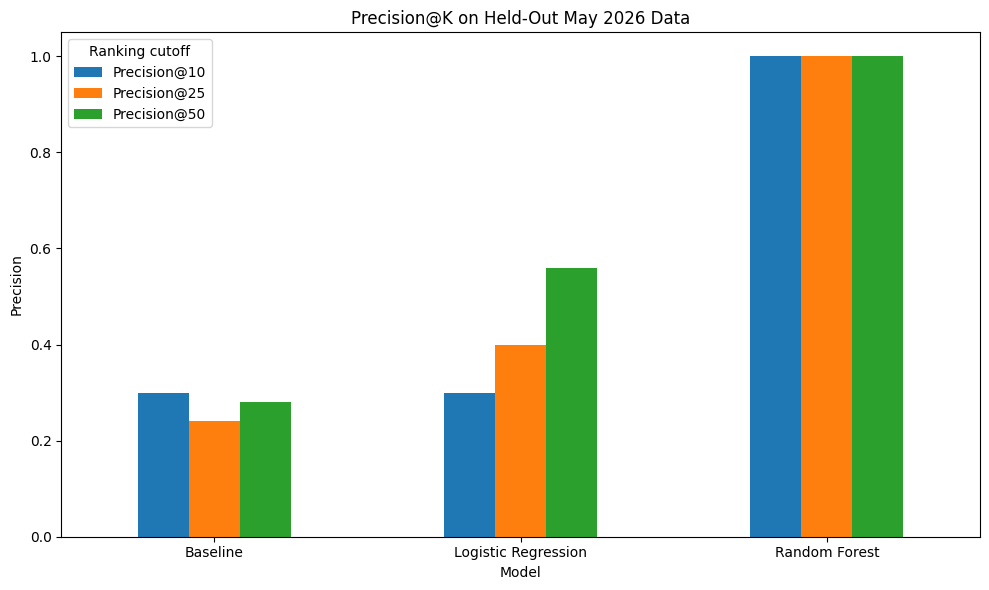

In [16]:
# Section 4: model comparison chart

plt.figure(figsize=(10, 6))

plot_data = results_table.set_index("Model")[
    ["Precision@10", "Precision@25", "Precision@50"]
]

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Precision@K on Held-Out May 2026 Data")
plt.ylabel("Precision")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(title="Ranking cutoff")
plt.tight_layout()

os.makedirs("outputs/charts", exist_ok=True)

plt.savefig(
    "outputs/charts/model_precision_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 5. Limitations

### Observational data

The analysis uses observational search and engagement data. It identifies patterns associated with future observed performance but does not establish causal relationships.

### No Google algorithm claim

The model does not explain, reproduce, or reverse-engineer Google's ranking algorithm. Search performance can be influenced by many factors that are not represented in the available data.

### No causal refresh claim

A high refresh score means that an item resembles historical cases associated with future performance decline. It does not prove that refreshing that content will improve clicks, rankings, traffic, or engagement.

### Historical generalization

The model is evaluated on a held-out time period, but future search behavior may differ from the historical period used for development.

### Unequal history

Content items can have different amounts of available history. Although the modeling dataset requires sufficient observations for the selected historical windows, the underlying panel remains unbalanced.

### Label dependence

The target depends on the selected historical and future observation windows. A different window or decline definition could produce different results.

### Missing signals

The available warehouse fields do not represent every factor that may influence search performance. The resulting ranking should therefore be treated as a prioritization aid rather than an automated decision.

### Public-safe output

Only pseudonymized identifiers and aggregate/model-derived information should be included in the public paper. Client names, domains, URLs, private queries, credentials, and raw exports are excluded.


In [17]:
# Section 5: quantify the data limitations

limitation_summary = pd.DataFrame({
    "Measure": [
        "Training rows",
        "Test rows",
        "Training unique content-client pairs",
        "Test unique content-client pairs",
        "Positive rate in training",
        "Positive rate in test",
        "Rows with complete historical feature set"
    ],
    "Value": [
        len(train_df),
        len(test_df),
        train_df[["client_hash_id", "content_hash_id"]]
            .drop_duplicates()
            .shape[0],
        test_df[["client_hash_id", "content_hash_id"]]
            .drop_duplicates()
            .shape[0],
        train_df[TARGET].mean(),
        test_df[TARGET].mean(),
        len(
            train_df.dropna(subset=FEATURES)
        )
    ]
})

display(limitation_summary)

,Measure,Value
0,Training rows,1.138872e+06
1,Test rows,7.369110e+05
2,Training unique content-client pairs,2.278400e+04
3,Test unique content-client pairs,2.468900e+04
4,Positive rate in training,6.933088e-02
5,Positive rate in test,6.664848e-02
6,Rows with complete historical feature set,3.012250e+05


In [18]:
# Section 5: check historical observation depth

history_check = df["prior_click_observations"].describe()

display(history_check)

print(
    "Minimum prior observations:",
    df["prior_click_observations"].min()
)

print(
    "Maximum prior observations:",
    df["prior_click_observations"].max()
)

,prior_click_observations
count,2429109.0
mean,7.0
std,0.0
min,7.0
25%,7.0
50%,7.0
75%,7.0
max,7.0


Minimum prior observations: 7
Maximum prior observations: 7


## 6. Ranked recommendations

The final model is converted into a ranked refresh-review queue.

A higher score means that the content item received a higher model-estimated likelihood of the future-decline outcome on the held-out ranking task.

The queue is intended to prioritize human review rather than automatically prescribe a content change.

Reason codes are generated from the observed historical signals. These codes explain which signals contributed to the item's review priority.

Recommended actions are:

* **Review** for high-priority items with strong weakening signals.
* **Monitor** for moderate-priority items where the evidence is less strong.
* **Protect / monitor** for lower-priority items showing relatively stable historical behavior.

All identifiers in the public output remain pseudonymized.


In [19]:
# Section 6: create the ranked recommendation table

recommendations = test_df[
    [
        "report_date",
        "client_hash_id",
        "content_hash_id",
        "clicks_mean_7",
        "impressions_mean_7",
        "position_mean_7",
        "engagement_mean_7",
        "clicks_change_7",
        "impressions_change_7",
        "position_change_7",
        "engagement_change_7",
        TARGET
    ]
].copy()

recommendations["refresh_score"] = final_predictions

recommendations = recommendations.sort_values(
    "refresh_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    np.arange(len(recommendations)) + 1
)

display(
    recommendations[
        [
            "rank",
            "content_hash_id",
            "report_date",
            "refresh_score",
            TARGET
        ]
    ].head(50)
)

,rank,content_hash_id,report_date,refresh_score,future_decline
0,1,content_87aa6ef552f37f93,2026-05-19,0.997949,1
1,2,content_87aa6ef552f37f93,2026-05-20,0.997949,1
2,3,content_ccd652e3c5a73142,2026-05-01,0.997856,1
3,4,content_6f5f5c59387aa216,2026-05-17,0.997684,1
4,5,content_97a385e382135d17,2026-05-29,0.997596,1
5,6,content_c6ca30855da3867f,2026-05-15,0.997562,1
6,7,content_c6ca30855da3867f,2026-05-17,0.997562,1
7,8,content_c6ca30855da3867f,2026-05-16,0.997562,1
8,9,content_bc85da0031cd005e,2026-05-05,0.997562,1
9,10,content_bc85da0031cd005e,2026-05-09,0.997562,1


In [30]:
# Section 6: create reason codes

def create_reason_codes(row):
    reasons = []

    # Click deterioration
    if pd.notna(row["clicks_change_7"]) and row["clicks_change_7"] < 0:
        reasons.append("recent clicks weakening")

    # Impression deterioration
    if (
        pd.notna(row["impressions_change_7"])
        and row["impressions_change_7"] < 0
    ):
        reasons.append("recent impressions weakening")

    # Position deterioration
    # Higher average position number = weaker position.
    if (
        pd.notna(row["position_change_7"])
        and row["position_change_7"] > 0
    ):
        reasons.append("average position weakening")

    # Engagement deterioration
    if (
        pd.notna(row["engagement_change_7"])
        and row["engagement_change_7"] < 0
    ):
        reasons.append("engagement weakening")

    if not reasons:
        reasons.append("mixed or stable historical signals")

    return "; ".join(reasons)


recommendations["reason_codes"] = recommendations.apply(
    create_reason_codes,
    axis=1
)

# Simple action tier
def action_for_score(score):
    if score >= recommendations["refresh_score"].quantile(0.90):
        return "Review"
    elif score >= recommendations["refresh_score"].quantile(0.50):
        return "Monitor"
    else:
        return "Protect / monitor"


recommendations["recommended_action"] = (
    recommendations["refresh_score"]
    .apply(action_for_score)
)

display(
    recommendations[
        [
            "rank",
            "content_hash_id",
            "refresh_score",
            "reason_codes",
            "recommended_action"
        ]
    ].head(50)
)

KeyboardInterrupt: 

In [21]:
print("Recommendations rows:", len(recommendations))

Recommendations rows: 736911


In [22]:
# Section 6: create reason codes and action tiers

# ---------------------------------------------------------
# Reason codes
# ---------------------------------------------------------

conditions = [
    recommendations["clicks_change_7"].lt(0),
    recommendations["impressions_change_7"].lt(0),
    recommendations["position_change_7"].gt(0),
    recommendations["engagement_change_7"].lt(0),
]

recommendations["reason_codes"] = ""

recommendations.loc[
    conditions[0],
    "reason_codes"
] += "recent clicks weakening; "

recommendations.loc[
    conditions[1],
    "reason_codes"
] += "recent impressions weakening; "

recommendations.loc[
    conditions[2],
    "reason_codes"
] += "average position weakening; "

recommendations.loc[
    conditions[3],
    "reason_codes"
] += "engagement weakening; "

recommendations["reason_codes"] = (
    recommendations["reason_codes"]
    .str.rstrip("; ")
)

recommendations.loc[
    recommendations["reason_codes"].eq(""),
    "reason_codes"
] = "mixed or stable historical signals"


# ---------------------------------------------------------
# Action tiers
# ---------------------------------------------------------

review_threshold = recommendations["refresh_score"].quantile(0.90)
monitor_threshold = recommendations["refresh_score"].quantile(0.50)

recommendations["recommended_action"] = np.select(
    [
        recommendations["refresh_score"] >= review_threshold,
        recommendations["refresh_score"] >= monitor_threshold,
    ],
    [
        "Review",
        "Monitor",
    ],
    default="Protect / monitor"
)


# ---------------------------------------------------------
# Display top 50
# ---------------------------------------------------------

display(
    recommendations[
        [
            "rank",
            "content_hash_id",
            "refresh_score",
            "reason_codes",
            "recommended_action"
        ]
    ].head(50)
)

,rank,content_hash_id,refresh_score,reason_codes,recommended_action
0,1,content_87aa6ef552f37f93,0.997949,mixed or stable historical signals,Review
1,2,content_87aa6ef552f37f93,0.997949,mixed or stable historical signals,Review
2,3,content_ccd652e3c5a73142,0.997856,recent impressions weakening,Review
3,4,content_6f5f5c59387aa216,0.997684,mixed or stable historical signals,Review
4,5,content_97a385e382135d17,0.997596,mixed or stable historical signals,Review
5,6,content_c6ca30855da3867f,0.997562,mixed or stable historical signals,Review
6,7,content_c6ca30855da3867f,0.997562,mixed or stable historical signals,Review
7,8,content_c6ca30855da3867f,0.997562,mixed or stable historical signals,Review
8,9,content_bc85da0031cd005e,0.997562,mixed or stable historical signals,Review
9,10,content_bc85da0031cd005e,0.997562,mixed or stable historical signals,Review


In [23]:
# Section 6: save the top-ranked public-safe recommendation queue

os.makedirs("outputs", exist_ok=True)

top_recommendations = recommendations.head(50).copy()

top_recommendations.to_csv(
    "outputs/ranked_refresh_queue.csv",
    index=False
)

print("Saved:", "outputs/ranked_refresh_queue.csv")

display(top_recommendations.head(10))

Saved: outputs/ranked_refresh_queue.csv


,report_date,client_hash_id,content_hash_id,clicks_mean_7,impressions_mean_7,position_mean_7,engagement_mean_7,clicks_change_7,impressions_change_7,position_change_7,engagement_change_7,future_decline,refresh_score,rank,reason_codes,recommended_action
0,2026-05-19,client_3ffa76342f366962,content_87aa6ef552f37f93,0.142857,0.142857,0.0,0.0,0.142857,0.000000,-10.0,0.0,1,0.997949,1,mixed or stable historical signals,Review
1,2026-05-20,client_3ffa76342f366962,content_87aa6ef552f37f93,0.142857,0.142857,0.0,0.0,0.142857,0.000000,-10.0,0.0,1,0.997949,2,mixed or stable historical signals,Review
2,2026-05-01,client_62f4a7e64f5e0096,content_ccd652e3c5a73142,0.142857,0.142857,0.0,NaN,0.142857,-0.142857,-66.5,NaN,1,0.997856,3,recent impressions weakening,Review
3,2026-05-17,client_fef1a8f436438636,content_6f5f5c59387aa216,0.142857,0.428571,0.0,0.0,0.142857,0.142857,-8.0,0.0,1,0.997684,4,mixed or stable historical signals,Review
4,2026-05-29,client_2094c6eb080311d5,content_97a385e382135d17,0.142857,0.142857,1.0,0.0,0.142857,0.000000,-6.0,0.0,1,0.997596,5,mixed or stable historical signals,Review
5,2026-05-15,client_3ffa76342f366962,content_c6ca30855da3867f,0.142857,0.142857,0.0,0.0,0.142857,0.142857,NaN,0.0,1,0.997562,6,mixed or stable historical signals,Review
6,2026-05-17,client_3ffa76342f366962,content_c6ca30855da3867f,0.142857,0.142857,0.0,0.0,0.142857,0.142857,NaN,0.0,1,0.997562,7,mixed or stable historical signals,Review
7,2026-05-16,client_3ffa76342f366962,content_c6ca30855da3867f,0.142857,0.142857,0.0,0.0,0.142857,0.142857,NaN,0.0,1,0.997562,8,mixed or stable historical signals,Review
8,2026-05-05,client_3ffa76342f366962,content_bc85da0031cd005e,0.142857,0.142857,0.0,0.0,0.142857,0.142857,NaN,0.0,1,0.997562,9,mixed or stable historical signals,Review
9,2026-05-09,client_3ffa76342f366962,content_bc85da0031cd005e,0.142857,0.142857,0.0,0.0,0.142857,0.142857,NaN,0.0,1,0.997562,10,mixed or stable historical signals,Review


## 7. Artifacts the paper embeds

The paper will embed the model comparison chart, feature-importance chart, results table, and a public-safe ranked refresh queue.

The artifacts are generated directly from the held-out evaluation results so that the paper can be reproduced from the notebook.

No raw warehouse export or private client information is included in the artifacts.


In [24]:
# Section 7: save the results table

os.makedirs("outputs/charts", exist_ok=True)

results_table.to_csv(
    "outputs/model_results.csv",
    index=False
)

classification_metrics.to_csv(
    "outputs/classification_metrics.csv",
    index=False
)

print("Saved model result tables.")

Saved model result tables.


In [25]:
# Section 7: feature importance for Random Forest

# Access the trained Random Forest inside the pipeline
rf_estimator = rf_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
0,clicks_mean_7,0.564684
1,impressions_mean_7,0.234087
4,clicks_change_7,0.142166
2,position_mean_7,0.041024
5,impressions_change_7,0.011602
6,position_change_7,0.004890
3,engagement_mean_7,0.001244
7,engagement_change_7,0.000303
8,client_has_gsc,0.000000


<Figure size 1000x600 with 0 Axes>

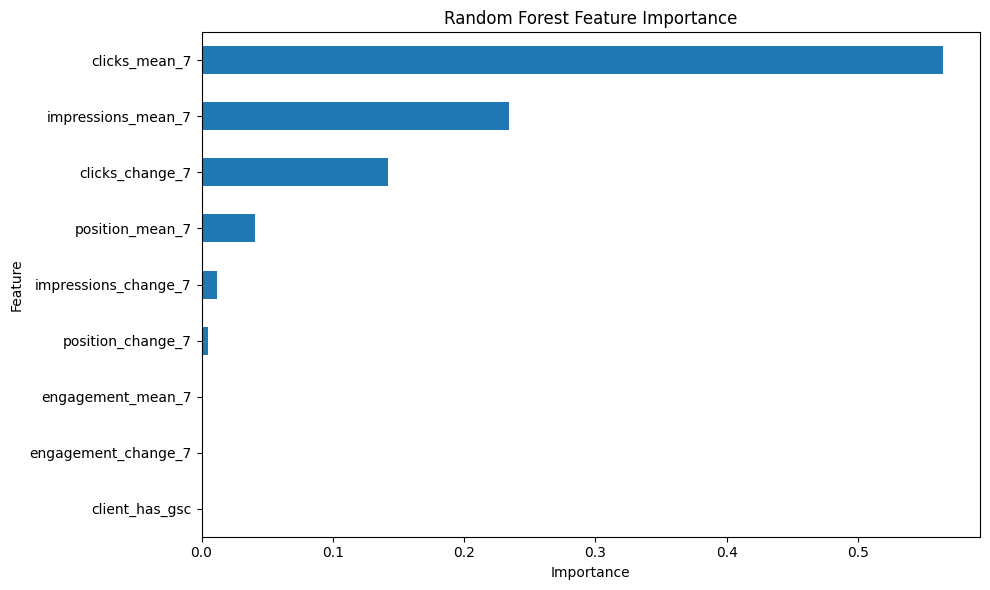

In [26]:
# Section 7: feature importance chart

plt.figure(figsize=(10, 6))

feature_importance.sort_values(
    "importance",
    ascending=True
).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "outputs/charts/feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

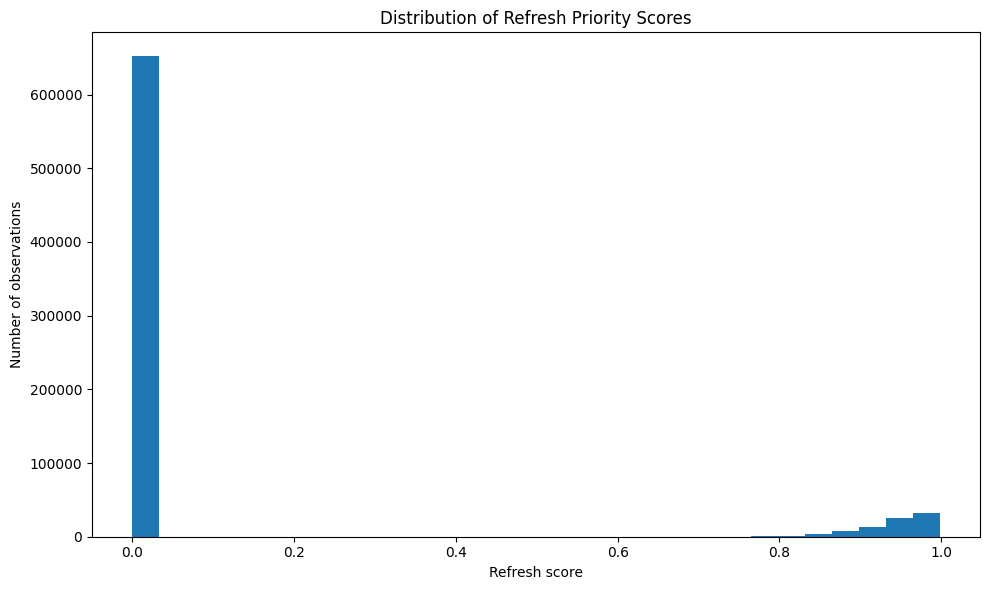

In [27]:
# Section 7: refresh score distribution

plt.figure(figsize=(10, 6))

plt.hist(
    recommendations["refresh_score"],
    bins=30
)

plt.title("Distribution of Refresh Priority Scores")
plt.xlabel("Refresh score")
plt.ylabel("Number of observations")
plt.tight_layout()

plt.savefig(
    "outputs/charts/refresh_score_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Section 7: verify generated artifacts

artifact_paths = [
    "outputs/model_results.csv",
    "outputs/classification_metrics.csv",
    "outputs/ranked_refresh_queue.csv",
    "outputs/charts/model_precision_comparison.png",
    "outputs/charts/feature_importance.png",
    "outputs/charts/refresh_score_distribution.png"
]

artifact_status = pd.DataFrame({
    "artifact": artifact_paths,
    "exists": [os.path.exists(path) for path in artifact_paths]
})

display(artifact_status)

if not artifact_status["exists"].all():
    raise FileNotFoundError(
        "One or more required artifacts were not generated."
    )

print("All required artifacts generated successfully.")

,artifact,exists
0,outputs/model_results.csv,True
1,outputs/classification_metrics.csv,True
2,outputs/ranked_refresh_queue.csv,True
3,outputs/charts/model_precision_comparison.png,True
4,outputs/charts/feature_importance.png,True
5,outputs/charts/refresh_score_distribution.png,True


All required artifacts generated successfully.


## Self-check

Before submitting, confirm each line honestly:

* [ ] Every section above is filled with both Markdown reasoning and supporting code.
* [ ] The notebook runs top to bottom with no errors using Runtime → Run all.
* [ ] The model uses a time-aware train/test split.
* [ ] Historical features use observations available before the prediction date.
* [ ] Future observations are used only to construct the future-decline label.
* [ ] No future-derived feature is included in the model feature list.
* [ ] Baseline and ML models are evaluated on the same held-out test period.
* [ ] Precision@10, Precision@25, and Precision@50 are reported.
* [ ] Model claims are based on the actual measured results.
* [ ] No client names, domains, URLs, private queries, credentials, or raw exports are included.
* [ ] Claims use careful language such as observed, measured, directional, and decision-support.
* [ ] The ranked recommendation queue contains only public-safe pseudonymized identifiers.
* [ ] The notebook is committed under `work/notebooks/`.
* [ ] The deployed paper contains all 9 required sections.
* [ ] The paper includes Acknowledgments & Data Credit with the FlyRank link.
* [ ] ML-12 closing deliverables are included: 5-minute demo outline, social-post cut, and 3-sentence employer-facing summary.


## ML-12 — 5-minute demo outline

### 0:00–0:30 — Problem

Explain that the project ranks anonymized content items for refresh review using historical search-performance signals.

### 0:30–1:00 — Data

Introduce the FlyRank internship warehouse and the daily content-performance table.

### 1:00–2:00 — Method

Explain the historical feature windows, future-decline label, leakage controls, and time-aware validation.

### 2:00–3:00 — Models

Show the transparent baseline, Logistic Regression, and Random Forest.

### 3:00–4:00 — Results

Show Precision@10, Precision@25, and Precision@50 on the held-out May 2026 period.

### 4:00–5:00 — Recommendations

Show the ranked refresh-review queue and explain how reason codes turn model scores into actionable review priorities.

The final conclusion should use decision-support language and avoid causal claims.


In [29]:
# ML-12: five-minute demo metrics

print("=== 5-MINUTE DEMO ===")
print()
print("Best model:", best_model_name)
print("Precision@10:",
      round(
          results_table.loc[
              results_table["Model"] == best_model_name,
              "Precision@10"
          ].iloc[0],
          4
      ))
print("Precision@25:",
      round(
          results_table.loc[
              results_table["Model"] == best_model_name,
              "Precision@25"
          ].iloc[0],
          4
      ))
print("Precision@50:",
      round(
          results_table.loc[
              results_table["Model"] == best_model_name,
              "Precision@50"
          ].iloc[0],
          4
      ))
print()
print("Top recommendation:")
display(
    recommendations[
        [
            "rank",
            "content_hash_id",
            "refresh_score",
            "reason_codes",
            "recommended_action"
        ]
    ].head(1)
)

=== 5-MINUTE DEMO ===

Best model: Random Forest
Precision@10: 1.0
Precision@25: 1.0
Precision@50: 1.0

Top recommendation:


,rank,content_hash_id,refresh_score,reason_codes,recommended_action
0,1,content_87aa6ef552f37f93,0.997949,mixed or stable historical signals,Review
